# Time-Based Stock Price Prediction for TSLA

### AIM : 
- Partition the dataset into training and testing subsets using an 80/20 time-based split.
- Develop a Linear Regression model for TSLA price prediction, incorporating lag features and technical indicators.
- Evaluate the model's performance using MAE, MSE, RMSE, and R2.
- Follow up with Decision Tree and Random Forest models, optimizing hyperparameters and visualizing feature importances.

## Importing Dependencies

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [6]:
df=pd.read_csv('TSLA.csv')

## Exploring the dataset

In [8]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [9]:
df.shape

(2416, 7)

In [10]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


## Feature Engineering

### a. Lag Features
Lag Features = Use past values to predict the future.

In [14]:
df['Close_lag1']=df['Close'].shift(1)
df['Close_lag2']=df['Close'].shift(2)

### b. Technical Indicators

Technical Indicators = Use formulas to find price patterns and trends.

#### Moving Average

In [18]:
df['MA7']=df['Close'].rolling(window=7).mean()
df['MA21']=df['Close'].rolling(window=21).mean()

MA(7) = average of last 7 days.
MA(21) = average of last 21 days.

In [20]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Close_lag1,Close_lag2,MA7,MA21
0,2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300,NaN,NaN,NaN,NaN
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100,23.889999,NaN,NaN,NaN
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800,23.830000,23.889999,NaN,NaN
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800,21.959999,23.830000,NaN,NaN
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900,19.200001,21.959999,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500,558.020020,564.820007,555.600010,499.660956
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500,566.900024,558.020020,565.670009,506.832860
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700,580.989990,566.900024,579.042864,517.600002
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300,640.809998,580.989990,590.615723,528.659050


In [21]:
# Dropping null values
df.dropna(inplace=True)

In [22]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Close_lag1,Close_lag2,MA7,MA21
20,2010-07-28,20.549999,20.900000,20.510000,20.719999,20.719999,467200,20.549999,20.950001,20.718571,19.911904
21,2010-07-29,20.770000,20.879999,20.000000,20.350000,20.350000,616000,20.719999,20.549999,20.725714,19.743333
22,2010-07-30,20.200001,20.440001,19.549999,19.940001,19.940001,426900,20.350000,20.719999,20.685714,19.558095
23,2010-08-02,20.500000,20.969999,20.330000,20.920000,20.920000,718100,19.940001,20.350000,20.674286,19.508571
24,2010-08-03,21.000000,21.950001,20.820000,21.950001,21.950001,1230500,20.920000,19.940001,20.768572,19.639524
...,...,...,...,...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500,558.020020,564.820007,555.600010,499.660956
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500,566.900024,558.020020,565.670009,506.832860
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700,580.989990,566.900024,579.042864,517.600002
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300,640.809998,580.989990,590.615723,528.659050


In [23]:
df['Date'] = pd.to_datetime(df['Date']) 

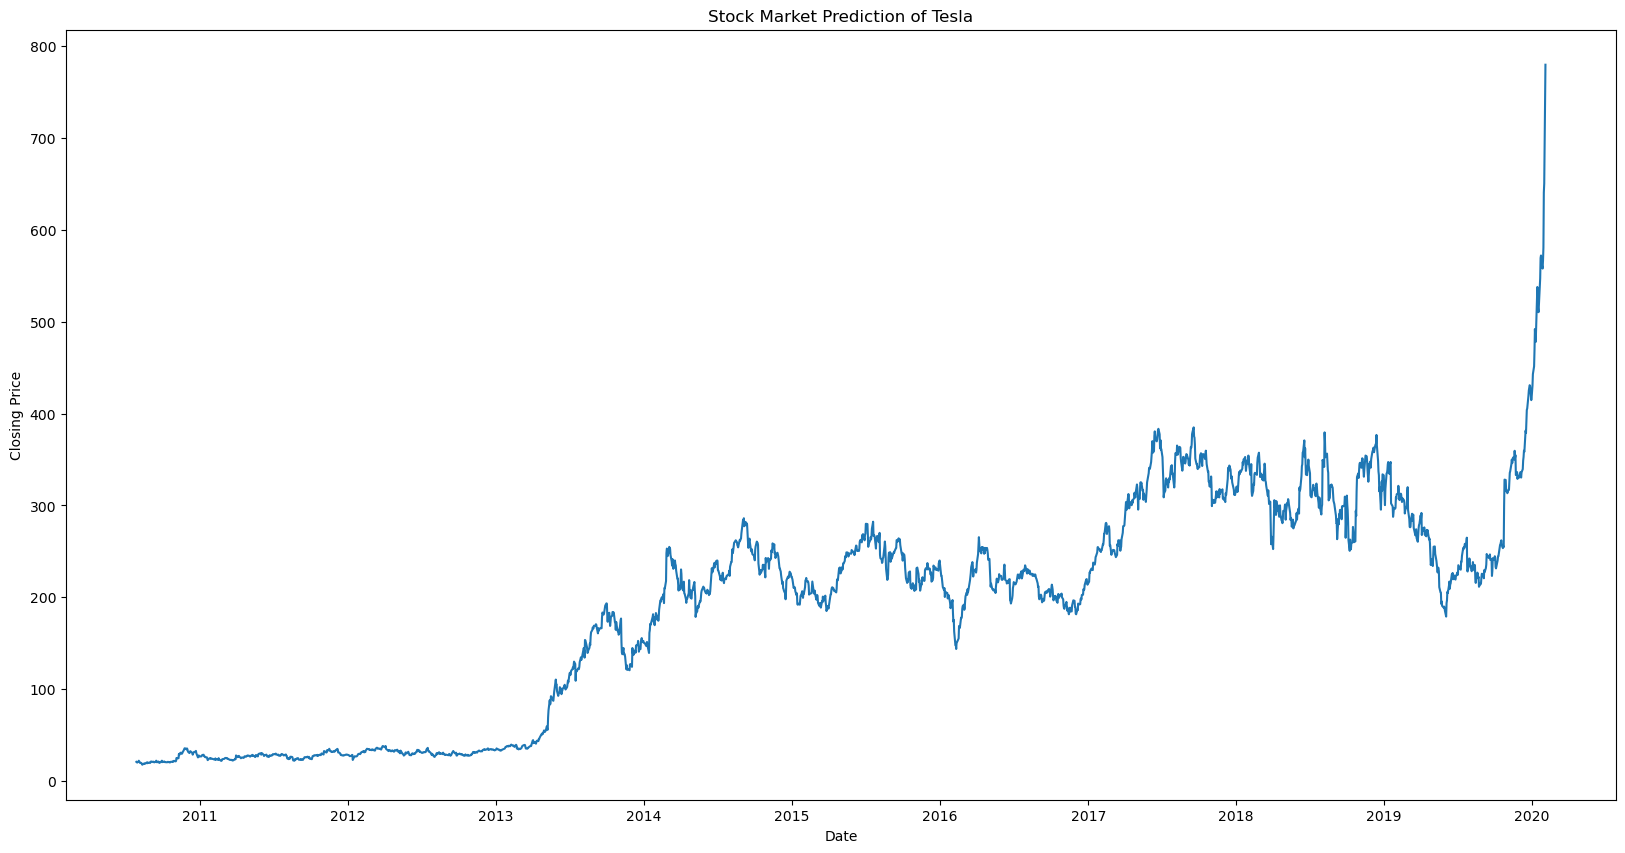

In [24]:
plt.figure(figsize=(20, 10))
plt.plot(df['Date'], df['Close'])
plt.title('Stock Market Prediction of Tesla')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

## Train-test split (80/20 time-based split)

In [26]:
split=int(len(df)*0.8)
print(split)

1916


In [27]:
train=df[:split]
test=df[split:]

In [28]:
X_train=train[['Close_lag1','Close_lag2','MA7','MA21']]
X_test=test[['Close_lag1','Close_lag2','MA7','MA21']]
y_train=train['Close']
y_test=test['Close']

In [29]:
lr=LinearRegression()

In [30]:
lr.fit(X_train,y_train)

LinearRegression()

In [31]:
y_pred=lr.predict(X_test)

## Performance Metrics

In [33]:
def performance_metrics(y_test,y_pred):
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    r2=r2_score(y_test,y_pred)
    print(f"MAE:{mae: .2f}, MSE:{mse: .2f}, RMSE:{rmse: .2f}, R2:{r2: .2f}")

In [34]:
print("Linear Regression Performance:")
performance_metrics(y_test,y_pred)

Linear Regression Performance:
MAE: 7.35, MSE: 146.09, RMSE: 12.09, R2: 0.97


## Decision Tree Regressor

### Hyperparameter tuning 
Hyperparameter tuning is the process of finding the best values for the model's settings (called hyperparameters) that control how the model learns.

In [37]:
params={'max_depth':[3,5,10,None],'min_samples_split':[2,5,10,23]}
tree=DecisionTreeRegressor()
grid_tree=GridSearchCV(tree,params,cv=3)
grid_tree.fit(X_train,y_train)
y_pred_tree=grid_tree.predict(X_test)
#best_tree=grid_tree.best_estimator_
print("Decision Tree Performance:")
performance_metrics(y_test,y_pred_tree)

Decision Tree Performance:
MAE: 18.11, MSE: 1926.33, RMSE: 43.89, R2: 0.63


## Random Forest Regressor + Feature Importance

In [39]:
params_rf={'n_estimators':[100,300],'max_depth':[5,10,None],'min_samples_split':[2,5,10]}
rf=RandomForestRegressor()
grid_rf=GridSearchCV(rf,params_rf,cv=3)
grid_rf.fit(X_train,y_train)
y_pred_rf=grid_rf.predict(X_test)
print("Random Forest Performance:")
performance_metrics(y_test,y_pred_rf)

Random Forest Performance:
MAE: 15.75, MSE: 1707.25, RMSE: 41.32, R2: 0.67


In [40]:
features=['Close_lag1','Close_lag2','MA7','MA21']
feature_importance=grid_rf.best_estimator_.feature_importances_
features_sort=pd.Series(feature_importance,index=features)

In [41]:
print(feature_importance)
print(features_sort)

[0.31486347 0.10339557 0.5714841  0.01025686]
Close_lag1    0.314863
Close_lag2    0.103396
MA7           0.571484
MA21          0.010257
dtype: float64


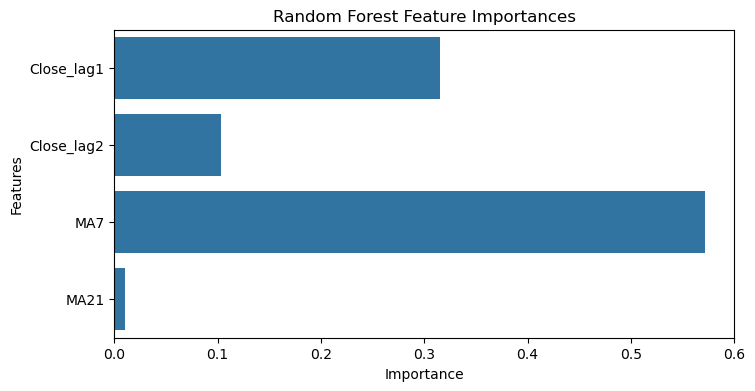

In [42]:
# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=features_sort.values,y=features_sort.index)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importances")
plt.show()

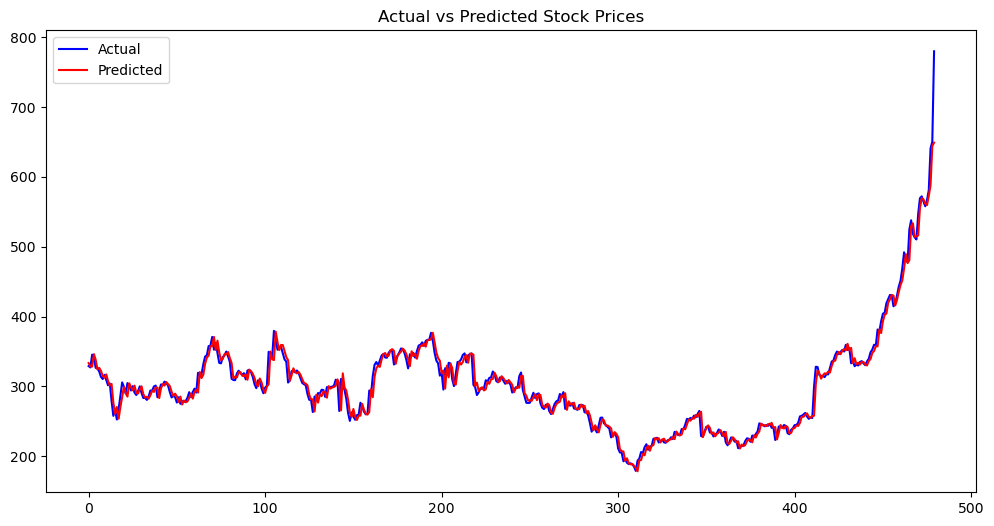

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual", color='blue')
plt.plot(y_pred, label="Predicted", color='red')
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.show()

By seeing the graph, we can see that Linear Regression model predicts almost accurately on the unseen samples.

In [80]:
# Example: Assuming the latest data
latest_data = [[
    1050,   # Close_lag1 (Yesterday's Close)
    1045,   # Close_lag2 (Day before yesterday's Close)
    1038,   # MA7 (Last 7-day average)
    1025    # MA21 (Last 21-day average)
]]

# Predict today's price
predicted_price = lr.predict(latest_data)

print(f"Predicted Today's Stock Price: ₹{predicted_price[0]:.2f}")

Predicted Today's Stock Price: ₹1047.92


D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Conculsion
In this study, I successfully developed predictive models for TSLA stock prices using time-series historical data. Among the models tested, the Linear Regression demonstrated superior performance, yielding lower error rates and higher R² compared to Random Forest Regressor and Decision Tree models. This suggests that it doesn’t overfit and works well when data relationships are actually linear.Short-term price changes often follow linear trends (especially when using lagged values and moving averages). Furthermore, the feature importance analysis provided valuable insights into which lag and technical indicators most influence price prediction. Overall, this project showcases the practical application of machine learning in financial forecasting and lays the groundwork for building more robust and scalable trading decision systems in the future.